In [1]:
import sys

if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
    !mkdir -p notebooks
    !mv utils.py notebooks
    !mkdir output

--2026-04-16 10:28:53--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2026-04-16 10:28:53 (48.6 MB/s) - ‘utils.py’ saved [771/771]



In [2]:
# NumPy for array and numerical operations
import numpy as np

# TensorFlow deep learning framework
import tensorflow as tf

# Keras API: datasets, layers, models, optimizers, callbacks
from tensorflow.keras import datasets, layers, models, optimizers, callbacks

# TensorFlow Probability (used for probabilistic outputs in PixelCNN)
import tensorflow_probability as tfp

# Custom helper function for displaying generated images/results
from notebooks.utils import display

In [3]:
# Input image size (PixelCNN will generate/process 32x32 images)
IMAGE_SIZE = 32

# Number of mixture components in output distribution (for PixelCNN-MD)
N_COMPONENTS = 5

# Number of full training passes over dataset
EPOCHS = 10

# Number of samples processed before updating model weights
BATCH_SIZE = 128

In [4]:
# Load Fashion-MNIST dataset
# x_train = training images
# labels are ignored (_) because PixelCNN is unsupervised (generative model)
(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Preprocessing function for input images
def preprocess(imgs):

    # Add channel dimension (28x28 → 28x28x1)
    imgs = np.expand_dims(imgs, -1)

    # Resize images to 32x32 (required for PixelCNN model)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()

    return imgs


# Apply preprocessing to training data
input_data = preprocess(x_train)

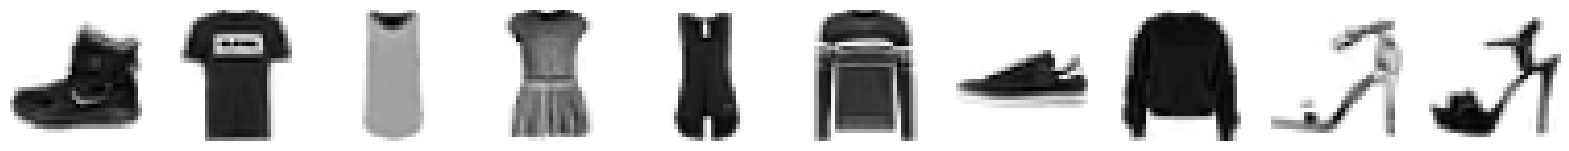

In [6]:
display(input_data)

In [7]:
# Define PixelCNN probabilistic distribution model (autoregressive image model)
#dist = tfp.distributions.PixelCNN(
    #image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),   # input image size
    #num_resnet=1,                              # number of ResNet blocks per level
    #num_hierarchies=2,                         # multi-scale hierarchy levels
    #num_filters=32,                            # convolution filters per layer
    #num_logistic_mix=N_COMPONENTS,             # mixture of logistics for pixel distribution
    #dropout_p=0.3,                             # dropout for regularization
#)

# Define input tensor for Keras model
#image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

# Compute log-likelihood of input image under PixelCNN distribution
#log_prob = dist.log_prob(image_input)

# Build Keras model mapping image → log probability
#pixelcnn = models.Model(inputs=image_input, outputs=log_prob)

# Add negative log-likelihood loss (maximize log_prob → minimize -log_prob)
#pixelcnn.add_loss(-tf.reduce_mean(log_prob))

In [8]:
# PixelCNN distribution
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=1,
    num_hierarchies=2,
    num_filters=32,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
)


# Custom model (NO Keras Functional API issues)
class PixelCNNModel(models.Model):

    def call(self, inputs, training=False):
        # Compute log probability directly
        log_prob = dist.log_prob(inputs)

        # Add loss inside model
        self.add_loss(-tf.reduce_mean(log_prob))

        return log_prob


# Create model
pixelcnn = PixelCNNModel()

I have rewritten the code myself because it was causing errors, and I have committed the changes to fix the issue.However logic is same

In [9]:
pixelcnn.compile(
    optimizer=optimizers.Adam(0.001),
)

In [10]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_images):
        super().__init__()
        self.num_images = num_images

    def generate(self):
        return dist.sample(self.num_images).numpy()

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.generate()
        display(
            generated_images,
            n=self.num_images,
            save_to=f"./output/generated_img_{epoch:03d}.png",
        )


img_generator_callback = ImageGenerator(num_images=2)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 4344.9048
Saved to ./output/generated_img_000.png


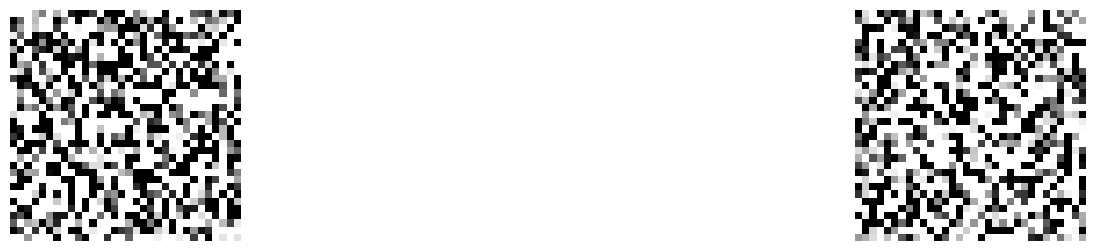

469/469 ━━━━━━━━━━━━━━━━━━━━ 147s 293ms/step - loss: 4341.2188
Epoch 2/5
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4336.7188
Saved to ./output/generated_img_001.png


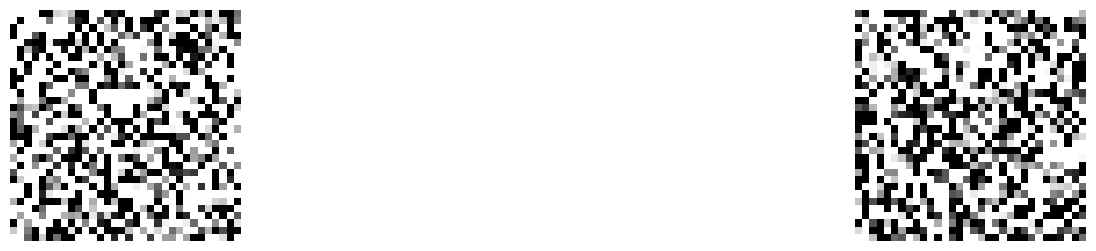

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 270ms/step - loss: 4341.2139
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4340.8525
Saved to ./output/generated_img_002.png


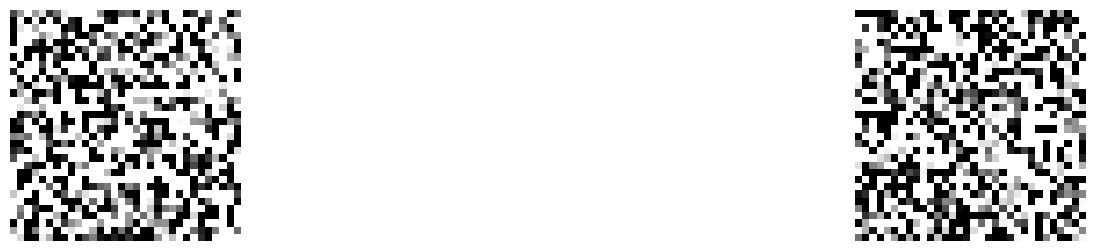

469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 271ms/step - loss: 4341.2202
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4339.2962
Saved to ./output/generated_img_003.png


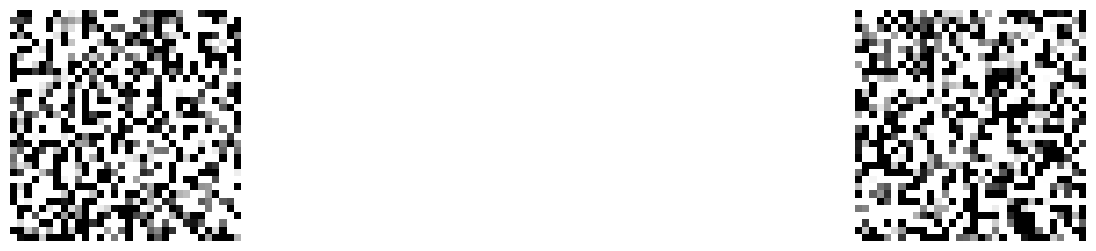

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 271ms/step - loss: 4341.2163
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4339.5369
Saved to ./output/generated_img_004.png


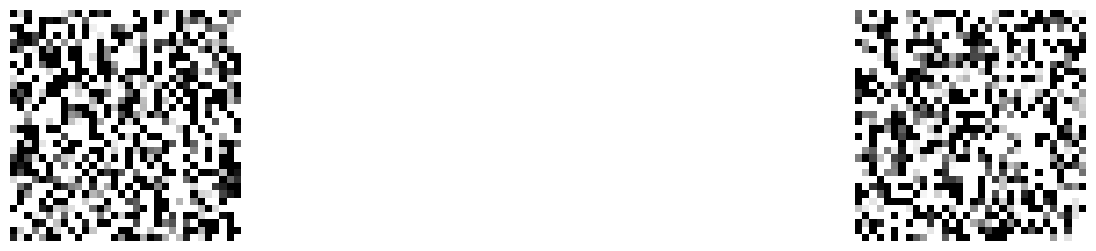

469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 272ms/step - loss: 4341.2173


In [11]:
EPOCHS = 5

pixelcnn.fit(
    input_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=True,
    callbacks=[tensorboard_callback, img_generator_callback],
)

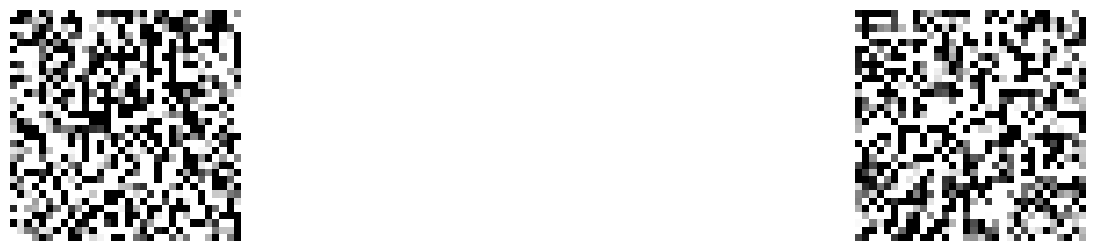

In [12]:
generated_images = img_generator_callback.generate()

display(
    generated_images,
    n=img_generator_callback.num_images
)

* In **05_autoregressive/02_pixelcnn/pixelcnn.ipynb**, the first PixelCNN treats image generation as a **discrete classification problem per pixel**, where each pixel is predicted from a small number of intensity levels, making it simpler, more stable, and easier to train.
* In **05_autoregressive/03_pixelcnn_md/pixelcnn_md.ipynb**, the PixelCNN-MD (TFP PixelCNN) models each pixel using a **continuous probability distribution (mixture of logistics)**, which is more expressive but significantly harder to train and more sensitive to preprocessing and normalization.
* The PixelCNN-MD requires **proper scaling, dequantization, and careful setup of likelihood modeling**, otherwise it may underperform.
* The first version generally converges faster and produces more stable results, while the second version can achieve higher-quality samples only when properly tuned and trained longer.
* Overall, the second notebook implements a more advanced and powerful generative model, but it is **more complex and less forgiving** compared to the first PixelCNN implementation.
